In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

import torch

from tqdm import tqdm

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
MODEL_PATH = (
    "/content/drive/MyDrive/FP_AI_2026/models/GraphCodeBERT_Model"
)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH
)

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model.to(device)

model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [ ]:
test_df = pd.read_csv(
    "/content/drive/MyDrive/FP_AI_2026/data/test.csv"
)

print(
    test_df.shape
)

(100, 2)


In [ ]:
def predict_codes(df):

    preds = []

    probs = []

    for code in tqdm(
        df["Sample_Code"]
    ):

        tokens = tokenizer(
            str(code),
            truncation=True,
            padding="max_length",
            max_length=256,
            return_tensors="pt"
        )

        tokens = {
            k:v.to(device)
            for k,v in tokens.items()
        }

        with torch.no_grad():

            outputs = model(
                **tokens
            )

            prob = torch.softmax(
                outputs.logits,
                dim=1
            )

        ai_prob = prob[0][0].item()

        pred = torch.argmax(
            prob,
            dim=1
        ).item()

        pred = 1 - pred

        probs.append(
            ai_prob
        )

        preds.append(
            pred
        )

    return (
        np.array(preds),
        np.array(probs)
    )

In [ ]:
preds, probs = predict_codes(
    test_df
)

100%|██████████| 100/100 [02:10<00:00,  1.31s/it]


In [ ]:
y_true = test_df["Label"]

print(
    classification_report(
        y_true,
        preds
    )
)

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        50
           1       0.98      1.00      0.99        50

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



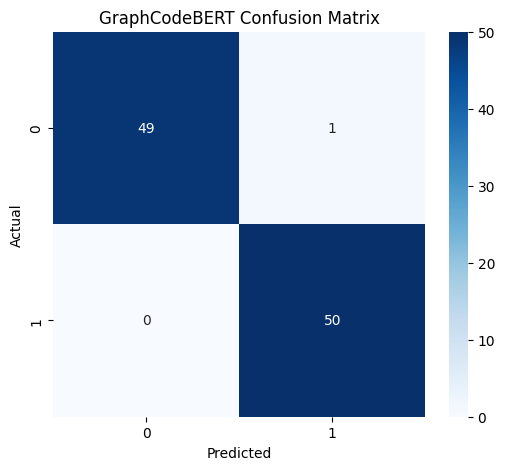

In [ ]:
cm = confusion_matrix(
    y_true,
    preds
)

plt.figure(
    figsize=(6,5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "GraphCodeBERT Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

In [ ]:
error_df = test_df.copy()

error_df["Prediction"] = preds

error_df["Correct"] = (
    error_df["Label"]
    ==
    error_df["Prediction"]
)

error_df.head()

,Sample_Code,Label,Prediction,Correct
0,#include <iostream>\n#include <vector>\n\nusin...,1,1,True
1,import Java.util.Scanner;\n\npublic class Main...,0,0,True
2,public class BinarySearchTree {\n\n // Root...,0,1,False
3,#include <iostream>\n#include <cmath>\n\ndoubl...,1,1,True
4,import Java.util.Scanner;\n\npublic class Plus...,1,1,True


In [ ]:
fp_df = error_df[

    (error_df["Label"] == 0)

    &

    (error_df["Prediction"] == 1)

]

print(
    "False Positive:",
    len(fp_df)
)

False Positive: 1


In [ ]:
fn_df = error_df[

    (error_df["Label"] == 1)

    &

    (error_df["Prediction"] == 0)

]

print(
    "False Negative:",
    len(fn_df)
)

False Negative: 0


In [ ]:
errors_df = error_df[

    error_df["Correct"]
    ==
    False

]

print(
    errors_df.shape
)

errors_df[
    [
        "Label",
        "Prediction"
    ]
]

(1, 4)


,Label,Prediction
2,0,1


In [ ]:
for idx,row in fp_df.iterrows():

    print("="*100)

    print(
        "TRUE:",
        row["Label"]
    )

    print(
        "PRED:",
        row["Prediction"]
    )

    print()

    print(
        row["Sample_Code"][:2000]
    )

TRUE: 0
PRED: 1

public class BinarySearchTree {

    // Root of BST
    BstNode root;

    BinarySearchTree() {
        root = null;
    }

    void Insert(int data) {
        root = Insert(root, data);
    }

    BstNode Insert(BstNode root, int data) {

        if (root == null) {
            root = new BstNode(data);
        } else if (data < root.data)
            root.Left = Insert(root.Left, data);
        else if (data > root.data)
            root.Right = Insert(root.Right, data);

        return root;
    }

    void InOrder() {
        InOrder(root);
    }

    void InOrder(BstNode root) {
        if (root != null) {
            InOrder(root.Left);
            System.out.print(root.data + " ");
            InOrder(root.Right);
        }
    }

    void PreOrder() {
        PreOrder(root);
    }

    void PreOrder(BstNode root) {
        if (root == null)
            return;
        System.out.print(root.data + " ");
        PreOrder(root.Left);
        PreOrder(root.Right);


In [ ]:
for idx,row in fn_df.iterrows():

    print("="*100)

    print(
        "TRUE:",
        row["Label"]
    )

    print(
        "PRED:",
        row["Prediction"]
    )

    print()

    print(
        row["Sample_Code"][:2000]
    )

In [ ]:
SAVE_DIR = (
    "/content/drive/MyDrive/FP_AI_2026/compare/"
)

fp_df.to_csv(
    SAVE_DIR + "graphcodebert_false_positive.csv",
    index=False
)

fn_df.to_csv(
    SAVE_DIR + "graphcodebert_false_negative.csv",
    index=False
)

summary = pd.DataFrame({

    "Model":[
        "GraphCodeBERT"
    ],

    "False_Positive":[
        len(fp_df)
    ],

    "False_Negative":[
        len(fn_df)
    ],

    "Total_Error":[
        len(fp_df) + len(fn_df)
    ]
})

summary.to_csv(
    SAVE_DIR + "graphcodebert_error_summary.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


In [ ]:
print("="*50)

print(
    "TOTAL TEST:",
    len(test_df)
)

print(
    "CORRECT:",
    error_df["Correct"].sum()
)

print(
    "ERROR:",
    len(errors_df)
)

print(
    "FALSE POSITIVE:",
    len(fp_df)
)

print(
    "FALSE NEGATIVE:",
    len(fn_df)
)

print("="*50)

TOTAL TEST: 100
CORRECT: 99
ERROR: 1
FALSE POSITIVE: 1
FALSE NEGATIVE: 0


In [ ]:
print("False Positive:", len(fp_df))
print("False Negative:", len(fn_df))

False Positive: 1
False Negative: 0
